# Vertical sections

A 2-D field that is not a map is drawn as a filled contour section. The meridional
overturning circulation is the natural example: it comes out of POP already as
latitude by depth.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # registers the cftime axis converter for matplotlib
import x4c

x4c.set_style('journal')

# after set_style: it resets rcParams from matplotlibrc defaults, which includes the
# backend, so assert the inline backend last or figures are never captured
%matplotlib inline

# The tutorial runs against a reduced copy of a real CESM case. It is published as a
# GitHub Release asset rather than committed, so the first call downloads it into
# ~/.cache/x4c (override with $X4C_CACHE_DIR) and later calls reuse it. Set
# $X4C_SAMPLE_DIR to point at a copy you already have.
case_dir = x4c.fetch_sample_data(case='cesm1', verbose=False)
casename = os.path.basename(case_dir)
print('x4c', x4c.__version__)

x4c 2026.6.11


In [2]:
moc_path = os.path.join(
    case_dir, 'ocn', 'proc', 'tseries', 'month_1',
    f'{casename}.pop.h.MOC.000101-000512.nc',
)
ds_moc = x4c.open_dataset(moc_path, comp='ocn', grid='g16', vn='MOC', shift_time=True)

moc = ds_moc.x.da.isel(transport_reg=0, moc_comp=0).mean('time')
moc = moc.rename({'moc_z': 'z_t', 'lat_aux_grid': 'lat'})
moc['z_t'] = moc['z_t'] / 1e5          # cm -> km
moc['z_t'].attrs['units'] = 'km'
moc.attrs['long_name'] = 'Meridional Ocean Circulation'
print(dict(moc.sizes))

{'z_t': 61, 'lat': 91}


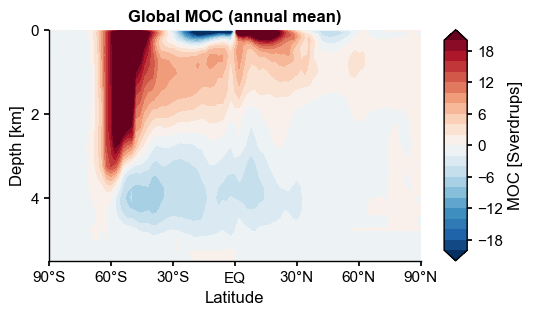

In [3]:
fig, ax = moc.x.plot(levels=np.linspace(-20, 20, 21),
                     title='Global MOC (annual mean)')
x4c.showfig(fig)